## 1. Imports

In [8]:
import os, pickle, warnings, platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from scipy import signal
from scipy.signal import butter, filtfilt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, LSTM, Input, concatenate, Permute
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)
print('TF:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)
print('Ready.')

TF: 2.19.0
GPU: True
Ready.


## 2. Configuration

> **IMPORTANT**: Change `DATA_PATH` to where your DEAP `.dat` files are.
> The folder should contain: `s01.dat`, `s02.dat` ... `s32.dat`

In [9]:
# ── PATHS ────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/madadimanjula/eeg-signals-dataset"
OUTPUT_PATH = "/kaggle/working"
# ─────────────────────────────────────────────────────────────────────

class Config:
    DATA_PATH   = DATA_PATH
    OUTPUT_PATH = OUTPUT_PATH

    N_SUBJECTS    = 32
    N_TRIALS      = 40
    N_CHANNELS    = 32
    SAMPLING_RATE = 128

    AROUSAL_THRESHOLD = 3.315
    VALENCE_THRESHOLD = 3.08

    WINDOW_SEC     = 4
    OVERLAP        = 0.5
    WINDOW_SAMPLES = 4 * 128    # 512
    STEP_SAMPLES   = 256

    BANDS = {
        'delta': (1,  4),
        'theta': (4,  8),
        'alpha': (8, 13),
        'beta' : (13, 30),
        'gamma': (30, 45),
    }

    BATCH_SIZE     = 64
    CNN_EPOCHS     = 60
    LSTM_EPOCHS    = 50
    CNNLSTM_EPOCHS = 60
    LR             = 5e-4

    CLASS_NAMES          = ['High Arousal', 'Low Arousal']
    N_CLASSES            = 2
    CONFIDENCE_THRESHOLD = 0.60
    COGNITIVE_STATES     = ['Positive', 'Stressed', 'Fatigued', 'Calm']

    TEST_SIZE = 0.20
    VAL_SIZE  = 0.15

cfg = Config()
os.makedirs(cfg.OUTPUT_PATH, exist_ok=True)

print('Configuration loaded.')
print(f'  Data path   : {cfg.DATA_PATH}')
print(f'  Output path : {cfg.OUTPUT_PATH}')
print(f'  Data exists : {os.path.exists(cfg.DATA_PATH)}')

if os.path.exists(cfg.DATA_PATH):
    dat_files = sorted([f for f in os.listdir(cfg.DATA_PATH) if f.endswith('.dat')])
    print(f'  .dat files  : {len(dat_files)} found')
    if dat_files:
        print(f'  Files       : {dat_files[:3]} ...')
    else:
        print('  WARNING: No .dat files found in this folder')
else:
    print('  WARNING: Path does not exist — check the path above')


Configuration loaded.
  Data path   : /kaggle/input/datasets/madadimanjula/eeg-signals-dataset
  Output path : /kaggle/working
  Data exists : True
  .dat files  : 32 found
  Files       : ['s01.dat', 's02.dat', 's03.dat'] ...


## 3. Data Loading

> Uses the full DEAP dataset  all 32 subjects, all 40 trials each.
> Arousal label is derived using median threshold (standard DEAP protocol).
> Valence score is stored separately  used later for cognitive state mapping.

In [10]:
def assign_label(arousal):
    """Binary arousal label. 0 = High Arousal, 1 = Low Arousal."""
    return 0 if arousal > cfg.AROUSAL_THRESHOLD else 1


def load_deap_data():
    all_data, all_labels, all_valence = [], [], []

    for subj in range(1, cfg.N_SUBJECTS + 1):
        fname = os.path.join(cfg.DATA_PATH, f's{subj:02d}.dat')
        if not os.path.exists(fname):
            fname = os.path.join(cfg.DATA_PATH, f's{subj}.dat')
        if not os.path.exists(fname):
            print(f'  [SKIP] {fname}')
            continue
        with open(fname, 'rb') as f:
            subject = pickle.load(f, encoding='latin1')

        data   = subject['data'][:, :cfg.N_CHANNELS, :]   # (40, 32, 8064)
        labels = subject['labels']                          # (40, 4)

        for trial in range(cfg.N_TRIALS):
            eeg     = data[trial]            # (32, 8064)
            arousal = labels[trial, 1]       # arousal rating 1-9
            valence = labels[trial, 0]       # valence rating 1-9
            label   = assign_label(arousal)

            # Sliding window segmentation
            n, start = eeg.shape[1], 0
            while start + cfg.WINDOW_SAMPLES <= n:
                all_data.append(eeg[:, start:start + cfg.WINDOW_SAMPLES])
                all_labels.append(label)
                all_valence.append(valence)
                start += cfg.STEP_SAMPLES

        if subj % 8 == 0:
            print(f'  Loaded {subj}/{cfg.N_SUBJECTS}...')

    all_data    = np.array(all_data,    dtype=np.float32)
    all_labels  = np.array(all_labels,  dtype=np.int32)
    all_valence = np.array(all_valence, dtype=np.float32)

    print(f'\nRaw windows: {len(all_labels)}')
    unique, counts = np.unique(all_labels, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  {cfg.CLASS_NAMES[u]:15s}: {c} ({100*c/len(all_labels):.1f}%)')

    # Balance classes via undersampling
    min_count = counts.min()
    bd, bl, bv = [], [], []
    for cls in unique:
        idx   = np.where(all_labels == cls)[0]
        idx_s = resample(idx, n_samples=min_count, random_state=42, replace=False)
        bd.append(all_data[idx_s])
        bl.append(all_labels[idx_s])
        bv.append(all_valence[idx_s])

    all_data    = np.concatenate(bd)
    all_labels  = np.concatenate(bl)
    all_valence = np.concatenate(bv)

    shuf        = np.random.RandomState(42).permutation(len(all_labels))
    all_data    = all_data[shuf]
    all_labels  = all_labels[shuf]
    all_valence = all_valence[shuf]

    print(f'\nBalanced windows: {len(all_labels)}')
    unique, counts = np.unique(all_labels, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  {cfg.CLASS_NAMES[u]:15s}: {c} ({100*c/len(all_labels):.1f}%)')

    return all_data, all_labels, all_valence


print('Loading DEAP dataset...')
raw_data, raw_labels, raw_valence = load_deap_data()

Loading DEAP dataset...
  Loaded 8/32...
  Loaded 16/32...
  Loaded 24/32...
  Loaded 32/32...

Raw windows: 38400
  High Arousal   : 19200 (50.0%)
  Low Arousal    : 19200 (50.0%)

Balanced windows: 38400
  High Arousal   : 19200 (50.0%)
  Low Arousal    : 19200 (50.0%)


## 4. Preprocessing

- **Bandpass filter 1–45 Hz**: removes DC drift and high-frequency muscle noise
- **Per-channel z-score normalization**: removes amplitude differences between subjects/electrodes

In [11]:
def bandpass_filter(data, lo=1.0, hi=45.0, fs=cfg.SAMPLING_RATE, order=5):
    nyq  = 0.5 * fs
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

def normalize_per_channel(data):
    mean = data.mean(axis=-1, keepdims=True)
    std  = data.std(axis=-1,  keepdims=True) + 1e-8
    return (data - mean) / std

print('Filtering (1-45 Hz bandpass)...')
filtered_data = bandpass_filter(raw_data).astype(np.float32)
print('Normalizing (per-channel z-score)...')
filtered_data = normalize_per_channel(filtered_data)
print(f'Done. Shape: {filtered_data.shape}')

Filtering (1-45 Hz bandpass)...
Normalizing (per-channel z-score)...
Done. Shape: (38400, 32, 512)


## 5. Feature Extraction

- **Band power (160-dim)**: Welch PSD averaged in each of 5 bands × 32 channels  for classical ML
- **Channel-band matrix (32×10)**: band powers + 5 clinical ratios  for CNN
- **Raw EEG (32×512)**: used directly by LSTM

In [12]:
def compute_band_power(window, fs=cfg.SAMPLING_RATE):
    freqs, psd = signal.welch(window, fs=fs,
                               nperseg=min(256, window.shape[-1]), axis=-1)
    feats = []
    for low, high in cfg.BANDS.values():
        idx = np.where((freqs >= low) & (freqs <= high))[0]
        feats.append(psd[:, idx].mean(axis=-1))
    return np.concatenate(feats)  # (160,)


def compute_channel_band_matrix(window, fs=cfg.SAMPLING_RATE):
    """
    Returns (32, 10) matrix:
    Cols 0-4 : band powers (delta, theta, alpha, beta, gamma)
    Cols 5-9 : clinical ratios
                theta/alpha  = drowsiness index
                beta/alpha   = cognitive activation
                theta/beta   = attention index
                (theta+alpha)/beta = engagement index
                gamma/beta   = high cognition index
    """
    freqs, psd = signal.welch(window, fs=fs,
                               nperseg=min(256, window.shape[-1]), axis=-1)
    bands = {}
    for name, (low, high) in cfg.BANDS.items():
        idx = np.where((freqs >= low) & (freqs <= high))[0]
        bands[name] = psd[:, idx].mean(axis=-1)

    bp  = np.stack(list(bands.values()), axis=-1)   # (32,5)
    eps = 1e-8
    r1  = bands['theta']  / (bands['alpha'] + eps)
    r2  = bands['beta']   / (bands['alpha'] + eps)
    r3  = bands['theta']  / (bands['beta']  + eps)
    r4  = (bands['theta'] + bands['alpha']) / (bands['beta'] + eps)
    r5  = bands['gamma']  / (bands['beta']  + eps)
    ratios = np.stack([r1,r2,r3,r4,r5], axis=-1)   # (32,5)
    return np.concatenate([bp, ratios], axis=-1)    # (32,10)


print('Extracting band power features (160-dim) for classical ML...')
X_band = np.array([compute_band_power(w) for w in filtered_data], dtype=np.float32)
print(f'  X_band: {X_band.shape}')

print('Extracting channel-band matrix (32x10) for CNN...')
X_2d = np.array([compute_channel_band_matrix(w) for w in filtered_data], dtype=np.float32)
print(f'  X_2d  : {X_2d.shape}')
print(f'  X_raw : {filtered_data.shape}  (used directly by LSTM)')
print('Done.')

Extracting band power features (160-dim) for classical ML...
  X_band: (38400, 160)
Extracting channel-band matrix (32x10) for CNN...
  X_2d  : (38400, 32, 10)
  X_raw : (38400, 32, 512)  (used directly by LSTM)
Done.


## 6. Train / Validation / Test Split

- **Test set (20%)**: held out from the very beginning  never seen during training or validation
- **Validation set (15% of training)**: used for early stopping and monitoring  model does NOT learn from it
- **Training set (remaining ~68%)**: model learns from this only

Normalization statistics computed from training set only to prevent data leakage.

In [13]:
indices = np.arange(len(raw_labels))

# Step 1: split off test set (20%) — never touched until final evaluation
idx_trainval, idx_test = train_test_split(
    indices, test_size=cfg.TEST_SIZE, random_state=42, stratify=raw_labels
)

# Step 2: split remaining into train + validation
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=cfg.VAL_SIZE, random_state=42,
    stratify=raw_labels[idx_trainval]
)

# Band power features
X_band_train = X_band[idx_train]
X_band_val   = X_band[idx_val]
X_band_test  = X_band[idx_test]

# Raw EEG
X_raw_train  = filtered_data[idx_train]
X_raw_val    = filtered_data[idx_val]
X_raw_test   = filtered_data[idx_test]

# 2D matrix — normalize using TRAIN stats only (prevents data leakage)
X_2d_mean  = X_2d[idx_train].mean(axis=0, keepdims=True)
X_2d_std   = X_2d[idx_train].std(axis=0,  keepdims=True) + 1e-8
X_2d_train = ((X_2d[idx_train] - X_2d_mean) / X_2d_std)[..., np.newaxis]
X_2d_val   = ((X_2d[idx_val]   - X_2d_mean) / X_2d_std)[..., np.newaxis]
X_2d_test  = ((X_2d[idx_test]  - X_2d_mean) / X_2d_std)[..., np.newaxis]

# Labels
y_train = raw_labels[idx_train]
y_val   = raw_labels[idx_val]
y_test  = raw_labels[idx_test]
v_train = raw_valence[idx_train]
v_val   = raw_valence[idx_val]
v_test  = raw_valence[idx_test]

y_train_cat = to_categorical(y_train, cfg.N_CLASSES)
y_val_cat   = to_categorical(y_val,   cfg.N_CLASSES)
y_test_cat  = to_categorical(y_test,  cfg.N_CLASSES)

cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))

print(f'Train : {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')
print(f'X_2d_train : {X_2d_train.shape}')
print(f'X_raw_train: {X_raw_train.shape}')
for i, cls in enumerate(cfg.CLASS_NAMES):
    print(f'  {cls}: train={np.sum(y_train==i)}, val={np.sum(y_val==i)}, test={np.sum(y_test==i)}')

Train : 26112 | Val: 4608 | Test: 7680
X_2d_train : (26112, 32, 10, 1)
X_raw_train: (26112, 32, 512)
  High Arousal: train=13056, val=2304, test=3840
  Low Arousal: train=13056, val=2304, test=3840


## 7. Classical ML — SVM, RF, LDA

- **SVM**: most cited method for EEG band-power classification
- **Random Forest**: noise-robust, gives feature importance
- **LDA**: classical BCI standard, fast and interpretable

All three report both **validation** and **test** accuracy.

In [14]:
scaler          = StandardScaler()
X_band_train_sc = scaler.fit_transform(X_band_train)
X_band_val_sc   = scaler.transform(X_band_val)
X_band_test_sc  = scaler.transform(X_band_test)

# Subsample for speed (SVM is slow on large datasets)
X_ml, y_ml = resample(X_band_train_sc, y_train,
                       n_samples=int(len(y_train)*0.15),
                       random_state=42, stratify=y_train)
print(f'ML subsample: {len(y_ml)} samples')

print('Training SVM...')
svm_model   = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_ml, y_ml)
svm_val_acc = accuracy_score(y_val,  svm_model.predict(X_band_val_sc))
svm_acc     = accuracy_score(y_test, svm_model.predict(X_band_test_sc))
print(f'  SVM  — Val: {svm_val_acc:.4f} | Test: {svm_acc:.4f}')

print('Training Random Forest...')
rf_model   = RandomForestClassifier(n_estimators=200, max_depth=20,
                                    random_state=42, n_jobs=-1)
rf_model.fit(X_ml, y_ml)
rf_val_acc = accuracy_score(y_val,  rf_model.predict(X_band_val_sc))
rf_acc     = accuracy_score(y_test, rf_model.predict(X_band_test_sc))
print(f'  RF   — Val: {rf_val_acc:.4f} | Test: {rf_acc:.4f}')

print('Training LDA...')
lda_model   = LinearDiscriminantAnalysis(solver='svd')
lda_model.fit(X_ml, y_ml)
lda_val_acc = accuracy_score(y_val,  lda_model.predict(X_band_val_sc))
lda_acc     = accuracy_score(y_test, lda_model.predict(X_band_test_sc))
print(f'  LDA  — Val: {lda_val_acc:.4f} | Test: {lda_acc:.4f}')

print('\nRandom Forest — Top 10 important features:')
fi     = rf_model.feature_importances_
top10  = np.argsort(fi)[::-1][:10]
bands_list = list(cfg.BANDS.keys())
for rank, feat_idx in enumerate(top10):
    ch   = feat_idx // len(cfg.BANDS)
    band = bands_list[feat_idx % len(cfg.BANDS)]
    print(f'  #{rank+1:2d}: Channel {ch:2d} — {band:5s}  (importance={fi[feat_idx]:.4f})')

ML subsample: 3916 samples
Training SVM...
  SVM  — Val: 0.6016 | Test: 0.6090
Training Random Forest...
  RF   — Val: 0.6209 | Test: 0.6247
Training LDA...
  LDA  — Val: 0.5929 | Test: 0.5979

Random Forest — Top 10 important features:
  # 1: Channel 14 — delta  (importance=0.0082)
  # 2: Channel 17 — delta  (importance=0.0081)
  # 3: Channel 23 — gamma  (importance=0.0079)
  # 4: Channel 19 — theta  (importance=0.0079)
  # 5: Channel  0 — delta  (importance=0.0078)
  # 6: Channel 30 — theta  (importance=0.0076)
  # 7: Channel 21 — beta   (importance=0.0076)
  # 8: Channel 21 — gamma  (importance=0.0076)
  # 9: Channel 11 — delta  (importance=0.0075)
  #10: Channel 25 — beta   (importance=0.0075)


## 8. CNN

**Architecture**: 3 × Conv2D (64→128→256 filters) + BatchNorm + Dropout > GlobalAvgPool > Dense (256→128) > Softmax

**Input**: (32, 10, 1) - 32 EEG channels × 10 features (band powers + clinical ratios)

**Why Conv2D**: Input is a 2D spatial grid. A 3×3 filter learns which channels AND which frequency bands activate together  spatial co-activation patterns that 1D convolution cannot capture.

In [15]:
def build_cnn(input_shape, n_classes=cfg.N_CLASSES):
    inp = Input(shape=input_shape)
    x = Conv2D(64,  (3,3), activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.35)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.35)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.25)(x)
    out = Dense(n_classes, activation='softmax')(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(cfg.LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn(X_2d_train.shape[1:])
cnn_model.summary()

cb_cnn = [
    EarlyStopping(patience=12, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=6, monitor='val_loss'),
    ModelCheckpoint(f'{cfg.OUTPUT_PATH}/best_cnn.keras',
                    save_best_only=True, monitor='val_accuracy')
]

print('Training CNN...')
cnn_history = cnn_model.fit(
    X_2d_train, y_train_cat,
    validation_data=(X_2d_val, y_val_cat),
    epochs=cfg.CNN_EPOCHS,
    batch_size=cfg.BATCH_SIZE,
    callbacks=cb_cnn,
    class_weight=cw_dict,
    verbose=1
)
cnn_val_acc = cnn_model.evaluate(X_2d_val,  y_val_cat,  verbose=0)[1]
cnn_acc     = cnn_model.evaluate(X_2d_test, y_test_cat, verbose=0)[1]
print(f'CNN  — Val: {cnn_val_acc:.4f} | Test: {cnn_acc:.4f}')

I0000 00:00:1776723603.091807      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776723603.097800      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 10, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 10, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,402 (1.79 MB)

 Trainable params: 469,506 (1.79 MB)

...

Training CNN...
Epoch 1/60


I0000 00:00:1776723607.764791     157 service.cc:152] XLA service 0x780a70008860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776723607.764839     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776723607.764844     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776723608.419348     157 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/408 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4884 - loss: 0.7266  

I0000 00:00:1776723615.593885     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


408/408 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.5227 - loss: 0.7147 - val_accuracy: 0.5221 - val_loss: 0.6921 - learning_rate: 5.0000e-04
Epoch 2/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5382 - loss: 0.6910 - val_accuracy: 0.5445 - val_loss: 0.6836 - learning_rate: 5.0000e-04
Epoch 3/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5478 - loss: 0.6870 - val_accuracy: 0.5510 - val_loss: 0.6803 - learning_rate: 5.0000e-04
Epoch 4/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5589 - loss: 0.6833 - val_accuracy: 0.5603 - val_loss: 0.6781 - learning_rate: 5.0000e-04
Epoch 5/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5627 - loss: 0.6817 - val_accuracy: 0.5690 - val_loss: 0.6770 - learning_rate: 5.0000e-04
Epoch 6/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5694 - loss: 0.6797 - val_accuracy: 0.5673 - val_loss: 0.6769 - learning_rate: 5.0000e-04
Epoch 7/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5

## 9. LSTM

**Architecture**: Permute > LSTM(128) > LSTM(64) > Dense(128) > Softmax

**Input**: (32, 512) raw EEG - 32 channels, 512 timesteps

**Why LSTM**: Reads the raw signal as a temporal sequence. Learns how brain activity evolves over the 4 second window - patterns that band power features lose by averaging over time.

In [16]:
def build_lstm(input_shape, n_classes=cfg.N_CLASSES):
    inp = Input(shape=input_shape)
    x = Permute((2,1))(inp)              # (512, 32) — time is sequence dim
    x = LSTM(128, return_sequences=True,  dropout=0.3)(x)
    x = LSTM(64,  return_sequences=False, dropout=0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation='softmax')(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(cfg.LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm(X_raw_train.shape[1:])
lstm_model.summary()

cb_lstm = [
    EarlyStopping(patience=12, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=6, monitor='val_loss'),
    ModelCheckpoint(f'{cfg.OUTPUT_PATH}/best_lstm.keras',
                    save_best_only=True, monitor='val_accuracy')
]

print('Training LSTM...')
lstm_history = lstm_model.fit(
    X_raw_train, y_train_cat,
    validation_data=(X_raw_val, y_val_cat),
    epochs=cfg.LSTM_EPOCHS,
    batch_size=cfg.BATCH_SIZE,
    callbacks=cb_lstm,
    class_weight=cw_dict,
    verbose=1
)
lstm_val_acc = lstm_model.evaluate(X_raw_val,  y_val_cat,  verbose=0)[1]
lstm_acc     = lstm_model.evaluate(X_raw_test, y_test_cat, verbose=0)[1]
print(f'LSTM — Val: {lstm_val_acc:.4f} | Test: {lstm_acc:.4f}')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 512, 128)       │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,418 (548.51 KB)

 Trainable params: 140,418 (548.51 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM...
Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.5149 - loss: 0.6946 - val_accuracy: 0.5799 - val_loss: 0.6736 - learning_rate: 5.0000e-04
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.5738 - loss: 0.6782 - val_accuracy: 0.5638 - val_loss: 0.6810 - learning_rate: 5.0000e-04
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.5632 - loss: 0.6790 - val_accuracy: 0.5588 - val_loss: 0.6828 - learning_rate: 5.0000e-04
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.5742 - loss: 0.6751 - val_accuracy: 0.5992 - val_loss: 0.6687 - learning_rate: 5.0000e-04
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.6002 - loss: 0.6659 - val_accuracy: 0.5605 - val_loss: 0.6789 - learning_rate: 5.0000e-04
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.5738 - loss: 0.6730 - val_accuracy: 0.5992 - val_loss: 0.6680 - learning_rate: 5.0000e-04
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━

## 10. CNN-LSTM Hybrid

**Two parallel streams**:
- Stream 1 (CNN): learns spatial channel-band patterns from the 32×10 matrix
- Stream 2 (LSTM): learns temporal dynamics from raw EEG
- Both streams concatenated > final dense layers > Softmax

Strongest single model because cognitive states have BOTH a spatial signature and a temporal signature.

In [17]:
def build_cnn_lstm(feat_shape, raw_shape, n_classes=cfg.N_CLASSES):
    # Stream 1: CNN — spatial patterns
    feat_inp = Input(shape=feat_shape, name='band_input')
    x = Conv2D(64,  (3,3), activation='relu', padding='same')(feat_inp)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.35)(x)

    # Stream 2: LSTM — temporal patterns
    raw_inp = Input(shape=raw_shape, name='raw_input')
    y = Permute((2,1))(raw_inp)
    y = LSTM(128, return_sequences=True,  dropout=0.3)(y)
    y = LSTM(64,  return_sequences=False, dropout=0.3)(y)
    y = Dense(128, activation='relu')(y)
    y = Dropout(0.35)(y)

    # Fusion: concatenate both representations
    merged = concatenate([x, y])
    z = Dense(256, activation='relu')(merged)
    z = Dropout(0.35)(z)
    z = Dense(128, activation='relu')(z)
    out = Dense(n_classes, activation='softmax')(z)

    model = Model(inputs=[feat_inp, raw_inp], outputs=out)
    model.compile(optimizer=Adam(cfg.LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_lstm_model = build_cnn_lstm(X_2d_train.shape[1:], X_raw_train.shape[1:])
cnn_lstm_model.summary()

cb_cl = [
    EarlyStopping(patience=12, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=6, monitor='val_loss'),
    ModelCheckpoint(f'{cfg.OUTPUT_PATH}/best_cnn_lstm.keras',
                    save_best_only=True, monitor='val_accuracy')
]

print('Training CNN-LSTM Hybrid...')
cnn_lstm_history = cnn_lstm_model.fit(
    [X_2d_train, X_raw_train], y_train_cat,
    validation_data=([X_2d_val, X_raw_val], y_val_cat),
    epochs=cfg.CNNLSTM_EPOCHS,
    batch_size=cfg.BATCH_SIZE,
    callbacks=cb_cl,
    class_weight=cw_dict,
    verbose=1
)
cl_val_acc   = cnn_lstm_model.evaluate([X_2d_val,  X_raw_val],  y_val_cat,  verbose=0)[1]
cnn_lstm_acc = cnn_lstm_model.evaluate([X_2d_test, X_raw_test], y_test_cat, verbose=0)[1]
print(f'CNN-LSTM — Val: {cl_val_acc:.4f} | Test: {cnn_lstm_acc:.4f}')

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ band_input          │ (None, 32, 10, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 10,    │        640 │ band_input[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 10,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raw_input           │ (None, 32, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 10,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 512, 32)   │          0 │ raw_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 10,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 512, 128)  │     82,432 │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      8,320 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     32,896 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 2)         │        258 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 330,882 (1.26 MB)

 Trainable params: 330,498 (1.26 MB)

 Non-trainable params: 384 (1.50 KB)

Training CNN-LSTM Hybrid...
Epoch 1/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.5239 - loss: 0.6957 - val_accuracy: 0.5701 - val_loss: 0.6790 - learning_rate: 5.0000e-04
Epoch 2/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.5766 - loss: 0.6774 - val_accuracy: 0.6011 - val_loss: 0.6662 - learning_rate: 5.0000e-04
Epoch 3/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.6048 - loss: 0.6672 - val_accuracy: 0.6079 - val_loss: 0.6610 - learning_rate: 5.0000e-04
Epoch 4/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.6087 - loss: 0.6627 - val_accuracy: 0.6124 - val_loss: 0.6612 - learning_rate: 5.0000e-04
Epoch 5/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.6145 - loss: 0.6590 - val_accuracy: 0.6076 - val_loss: 0.6633 - learning_rate: 5.0000e-04
Epoch 6/60
408/408 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.6179 - loss: 0.6591 - val_accuracy: 0.6105 - val_loss: 0.6610 - learning_rate: 5.0000e-04
Epoch 7/60
408/408 ━━━━━

## 11. Weighted Ensemble + Validation vs Test Summary

Combines all 6 models using weighted average of probability outputs.
Higher weight = more trusted model.
Also prints a full Val vs Test comparison table.

In [18]:
def get_all_probabilities(X_band_sc, X_2d, X_raw):
    return {
        'svm'     : svm_model.predict_proba(X_band_sc),
        'rf'      : rf_model.predict_proba(X_band_sc),
        'lda'     : lda_model.predict_proba(X_band_sc),
        'cnn'     : cnn_model.predict(X_2d,              verbose=0),
        'lstm'    : lstm_model.predict(X_raw,             verbose=0),
        'cnn_lstm': cnn_lstm_model.predict([X_2d, X_raw], verbose=0),
    }

def weighted_ensemble(probs_dict, weights=None):
    names = list(probs_dict.keys())
    if weights is None:
        weights = {n: 1.0 for n in names}
    total = sum(weights[n] for n in names)
    avg   = sum(probs_dict[n] * (weights[n]/total) for n in names)
    preds = np.argmax(avg, axis=1)
    confs = np.max(avg,    axis=1)
    return preds, confs, avg

ensemble_weights = {
    'svm':      1.0,
    'rf':       1.5,
    'lda':      0.5,
    'cnn':      2.5,
    'lstm':     2.5,
    'cnn_lstm': 3.5,
}

# Test set ensemble
print('Running ensemble on test set...')
test_probs              = get_all_probabilities(X_band_test_sc, X_2d_test, X_raw_test)
y_pred, confidences, _ = weighted_ensemble(test_probs, ensemble_weights)
ensemble_acc            = accuracy_score(y_test, y_pred)
uncertain               = np.sum(confidences < cfg.CONFIDENCE_THRESHOLD)

# Validation set ensemble
print('Running ensemble on validation set...')
val_probs                    = get_all_probabilities(X_band_val_sc, X_2d_val, X_raw_val)
y_val_pred, val_confs, _     = weighted_ensemble(val_probs, ensemble_weights)
ensemble_val_acc             = accuracy_score(y_val, y_val_pred)

print()
print(classification_report(y_test, y_pred, target_names=cfg.CLASS_NAMES))

# Full Val vs Test summary table
print('='*52)
print(f'  {"Model":<12} {"Val Acc":>10} {"Test Acc":>10}')
print('='*52)
print(f'  {"SVM":<12} {svm_val_acc:>10.4f} {svm_acc:>10.4f}')
print(f'  {"RF":<12} {rf_val_acc:>10.4f} {rf_acc:>10.4f}')
print(f'  {"LDA":<12} {lda_val_acc:>10.4f} {lda_acc:>10.4f}')
print(f'  {"CNN":<12} {cnn_val_acc:>10.4f} {cnn_acc:>10.4f}')
print(f'  {"LSTM":<12} {lstm_val_acc:>10.4f} {lstm_acc:>10.4f}')
print(f'  {"CNN-LSTM":<12} {cl_val_acc:>10.4f} {cnn_lstm_acc:>10.4f}')
print(f'  {"Ensemble":<12} {ensemble_val_acc:>10.4f} {ensemble_acc:>10.4f}')
print('='*52)
print(f'  Uncertain flags: {uncertain}/{len(confidences)}')

Running ensemble on test set...
Running ensemble on validation set...

              precision    recall  f1-score   support

High Arousal       0.66      0.68      0.67      3840
 Low Arousal       0.67      0.65      0.66      3840

    accuracy                           0.67      7680
   macro avg       0.67      0.67      0.67      7680
weighted avg       0.67      0.67      0.67      7680

  Model           Val Acc   Test Acc
  SVM              0.6016     0.6090
  RF               0.6209     0.6247
  LDA              0.5929     0.5979
  CNN              0.6534     0.6603
  LSTM             0.6135     0.6307
  CNN-LSTM         0.6330     0.6355
  Ensemble         0.6543     0.6665
  Uncertain flags: 3462/7680


## 12. Robustness Testing

Tests 4 real-world degradation conditions on the test set.
Measures accuracy drop vs clean baseline.

In [19]:
def degrade_noise(b, d2, r, level=0.3):
    return (b + np.random.normal(0, level*b.std(), b.shape)).astype(np.float32), \
           np.clip(d2 + np.random.normal(0, level*d2.std(), d2.shape), 0, None).astype(np.float32), \
           (r + np.random.normal(0, level*r.std(), r.shape)).astype(np.float32)

def degrade_missing_ch(b, d2, r, frac=0.25):
    drop = np.random.choice(cfg.N_CHANNELS, int(cfg.N_CHANNELS*frac), replace=False)
    r2 = r.copy(); r2[:, drop, :] = 0
    b2  = scaler.transform(np.array([compute_band_power(w) for w in r2], dtype=np.float32))
    d2n = ((np.array([compute_channel_band_matrix(w) for w in r2], dtype=np.float32)
             - X_2d_mean) / X_2d_std)[..., np.newaxis]
    return b2, d2n, r2.astype(np.float32)

def degrade_incomplete(b, d2, r, keep=0.6):
    r2 = r.copy(); r2[:, :, int(r.shape[-1]*keep):] = 0
    b2  = scaler.transform(np.array([compute_band_power(w) for w in r2], dtype=np.float32))
    d2n = ((np.array([compute_channel_band_matrix(w) for w in r2], dtype=np.float32)
             - X_2d_mean) / X_2d_std)[..., np.newaxis]
    return b2, d2n, r2.astype(np.float32)

def degrade_mask(b, d2, r, frac=0.3):
    d2c  = d2.copy()
    rows = np.random.choice(d2c.shape[1], int(d2c.shape[1]*frac), replace=False)
    d2c[:, rows, :, :] = 0
    return b, d2c.astype(np.float32), r

degradations = {
    'Gaussian noise (30%)'      : degrade_noise,
    'Missing channels (25%)'    : degrade_missing_ch,
    'Incomplete recording (60%)': degrade_incomplete,
    'Distorted input (30%)'     : degrade_mask,
}

rob_results = {}
print('Robustness tests...\n')
for name, fn in degradations.items():
    db, dd2, dr = fn(X_band_test_sc.copy(), X_2d_test.copy(), X_raw_test.copy())
    dp          = get_all_probabilities(db, dd2, dr)
    dp_pred, dp_conf, _ = weighted_ensemble(dp, ensemble_weights)
    acc  = accuracy_score(y_test, dp_pred)
    unc  = np.sum(dp_conf < cfg.CONFIDENCE_THRESHOLD)
    drop = ensemble_acc - acc
    rob_results[name] = {'accuracy': acc, 'drop': drop, 'uncertain': unc}
    print(f'  {name}')
    print(f'    Accuracy: {acc:.4f}  |  Drop: {drop:.4f}  |  Uncertain: {unc}')
print('\nRobustness complete.')

Robustness tests...

  Gaussian noise (30%)
    Accuracy: 0.6341  |  Drop: 0.0324  |  Uncertain: 6936
  Missing channels (25%)
    Accuracy: 0.5682  |  Drop: 0.0983  |  Uncertain: 4469
  Incomplete recording (60%)
    Accuracy: 0.6496  |  Drop: 0.0169  |  Uncertain: 3874
  Distorted input (30%)
    Accuracy: 0.6312  |  Drop: 0.0353  |  Uncertain: 3929

Robustness complete.


Plotting robustness results...


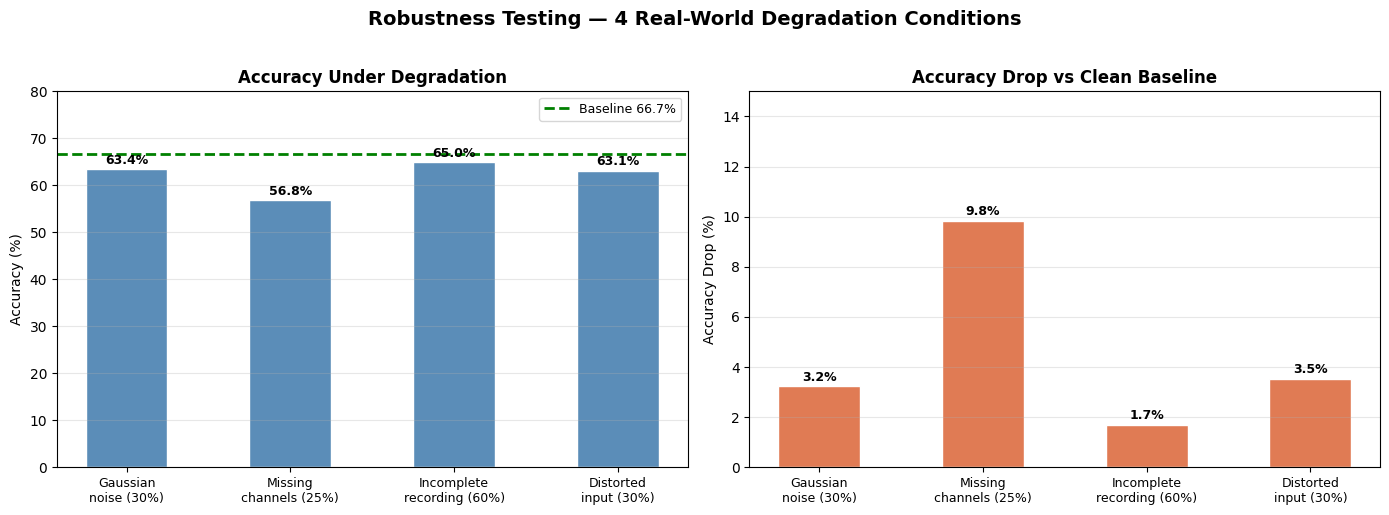

Robustness plot complete. Saved robustness_results.png


In [20]:
# ── Robustness Results Visualization ─────────────────────────────────
print('Plotting robustness results...')

conditions = [
    'Gaussian\nnoise (30%)',
    'Missing\nchannels (25%)',
    'Incomplete\nrecording (60%)',
    'Distorted\ninput (30%)'
]

rob_acc   = [rob_results[n]['accuracy'] * 100 for n in rob_results]
rob_drops = [rob_results[n]['drop']     * 100 for n in rob_results]

fig = plt.figure(figsize=(14, 5))

# ── 1: Accuracy vs Baseline ───────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
x     = np.arange(len(conditions))
width = 0.35
bars1 = ax1.bar(x, rob_acc, width=0.5, color='#5B8DB8', edgecolor='white')
ax1.axhline(ensemble_acc * 100, color='green', ls='--', lw=2,
            label=f'Baseline {ensemble_acc*100:.1f}%')
for bar, acc in zip(bars1, rob_acc):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(conditions, fontsize=9)
ax1.set_ylim(0, 80)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Under Degradation', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── 2: Accuracy Drop ─────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
bars2 = ax2.bar(x, rob_drops, width=0.5, color='#E07B54', edgecolor='white')
for bar, drop in zip(bars2, rob_drops):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{drop:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(conditions, fontsize=9)
ax2.set_ylim(0, 15)
ax2.set_ylabel('Accuracy Drop (%)')
ax2.set_title('Accuracy Drop vs Clean Baseline', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Robustness Testing — 4 Real-World Degradation Conditions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_PATH}/robustness_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Robustness plot complete. Saved robustness_results.png')

## 13. Cognitive State Interpretation

Maps model output + valence score onto Russell's Circumplex Model of Affect:
- High Arousal + Positive Valence > **Positive**
- High Arousal + Negative Valence > **Stressed**
- Low Arousal  + Negative Valence > **Fatigued**
- Low Arousal  + Positive Valence > **Calm**

Note: Arousal is predicted by the model. Valence comes from DEAP labels.

In [21]:
def interpret_cognitive_state(arousal_pred, valence_score):
    if arousal_pred == 0 and valence_score > cfg.VALENCE_THRESHOLD:
        return 'Positive'
    elif arousal_pred == 0 and valence_score <= cfg.VALENCE_THRESHOLD:
        return 'Stressed'
    elif arousal_pred == 1 and valence_score <= cfg.VALENCE_THRESHOLD:
        return 'Fatigued'
    else:
        return 'Calm'

cognitive_states = [
    interpret_cognitive_state(int(y_pred[i]), float(v_test[i]))
    for i in range(len(y_pred))
]

state_counts = Counter(cognitive_states)
print('Cognitive State Distribution (test set):')
print('-' * 45)
for state in ['Positive', 'Stressed', 'Fatigued', 'Calm']:
    count = state_counts.get(state, 0)
    pct   = 100 * count / len(cognitive_states)
    bar   = chr(9608) * int(pct / 2)
    print(f'  {state:10s}: {count:5d} ({pct:.1f}%) {bar}')

Cognitive State Distribution (test set):
---------------------------------------------
  Positive  :  2226 (29.0%) ██████████████
  Stressed  :  1745 (22.7%) ███████████
  Fatigued  :  2086 (27.2%) █████████████
  Calm      :  1623 (21.1%) ██████████


## 14. Visualization

Running EDA...
Dataset shape : (38400, 32, 512)
Total windows : 38400



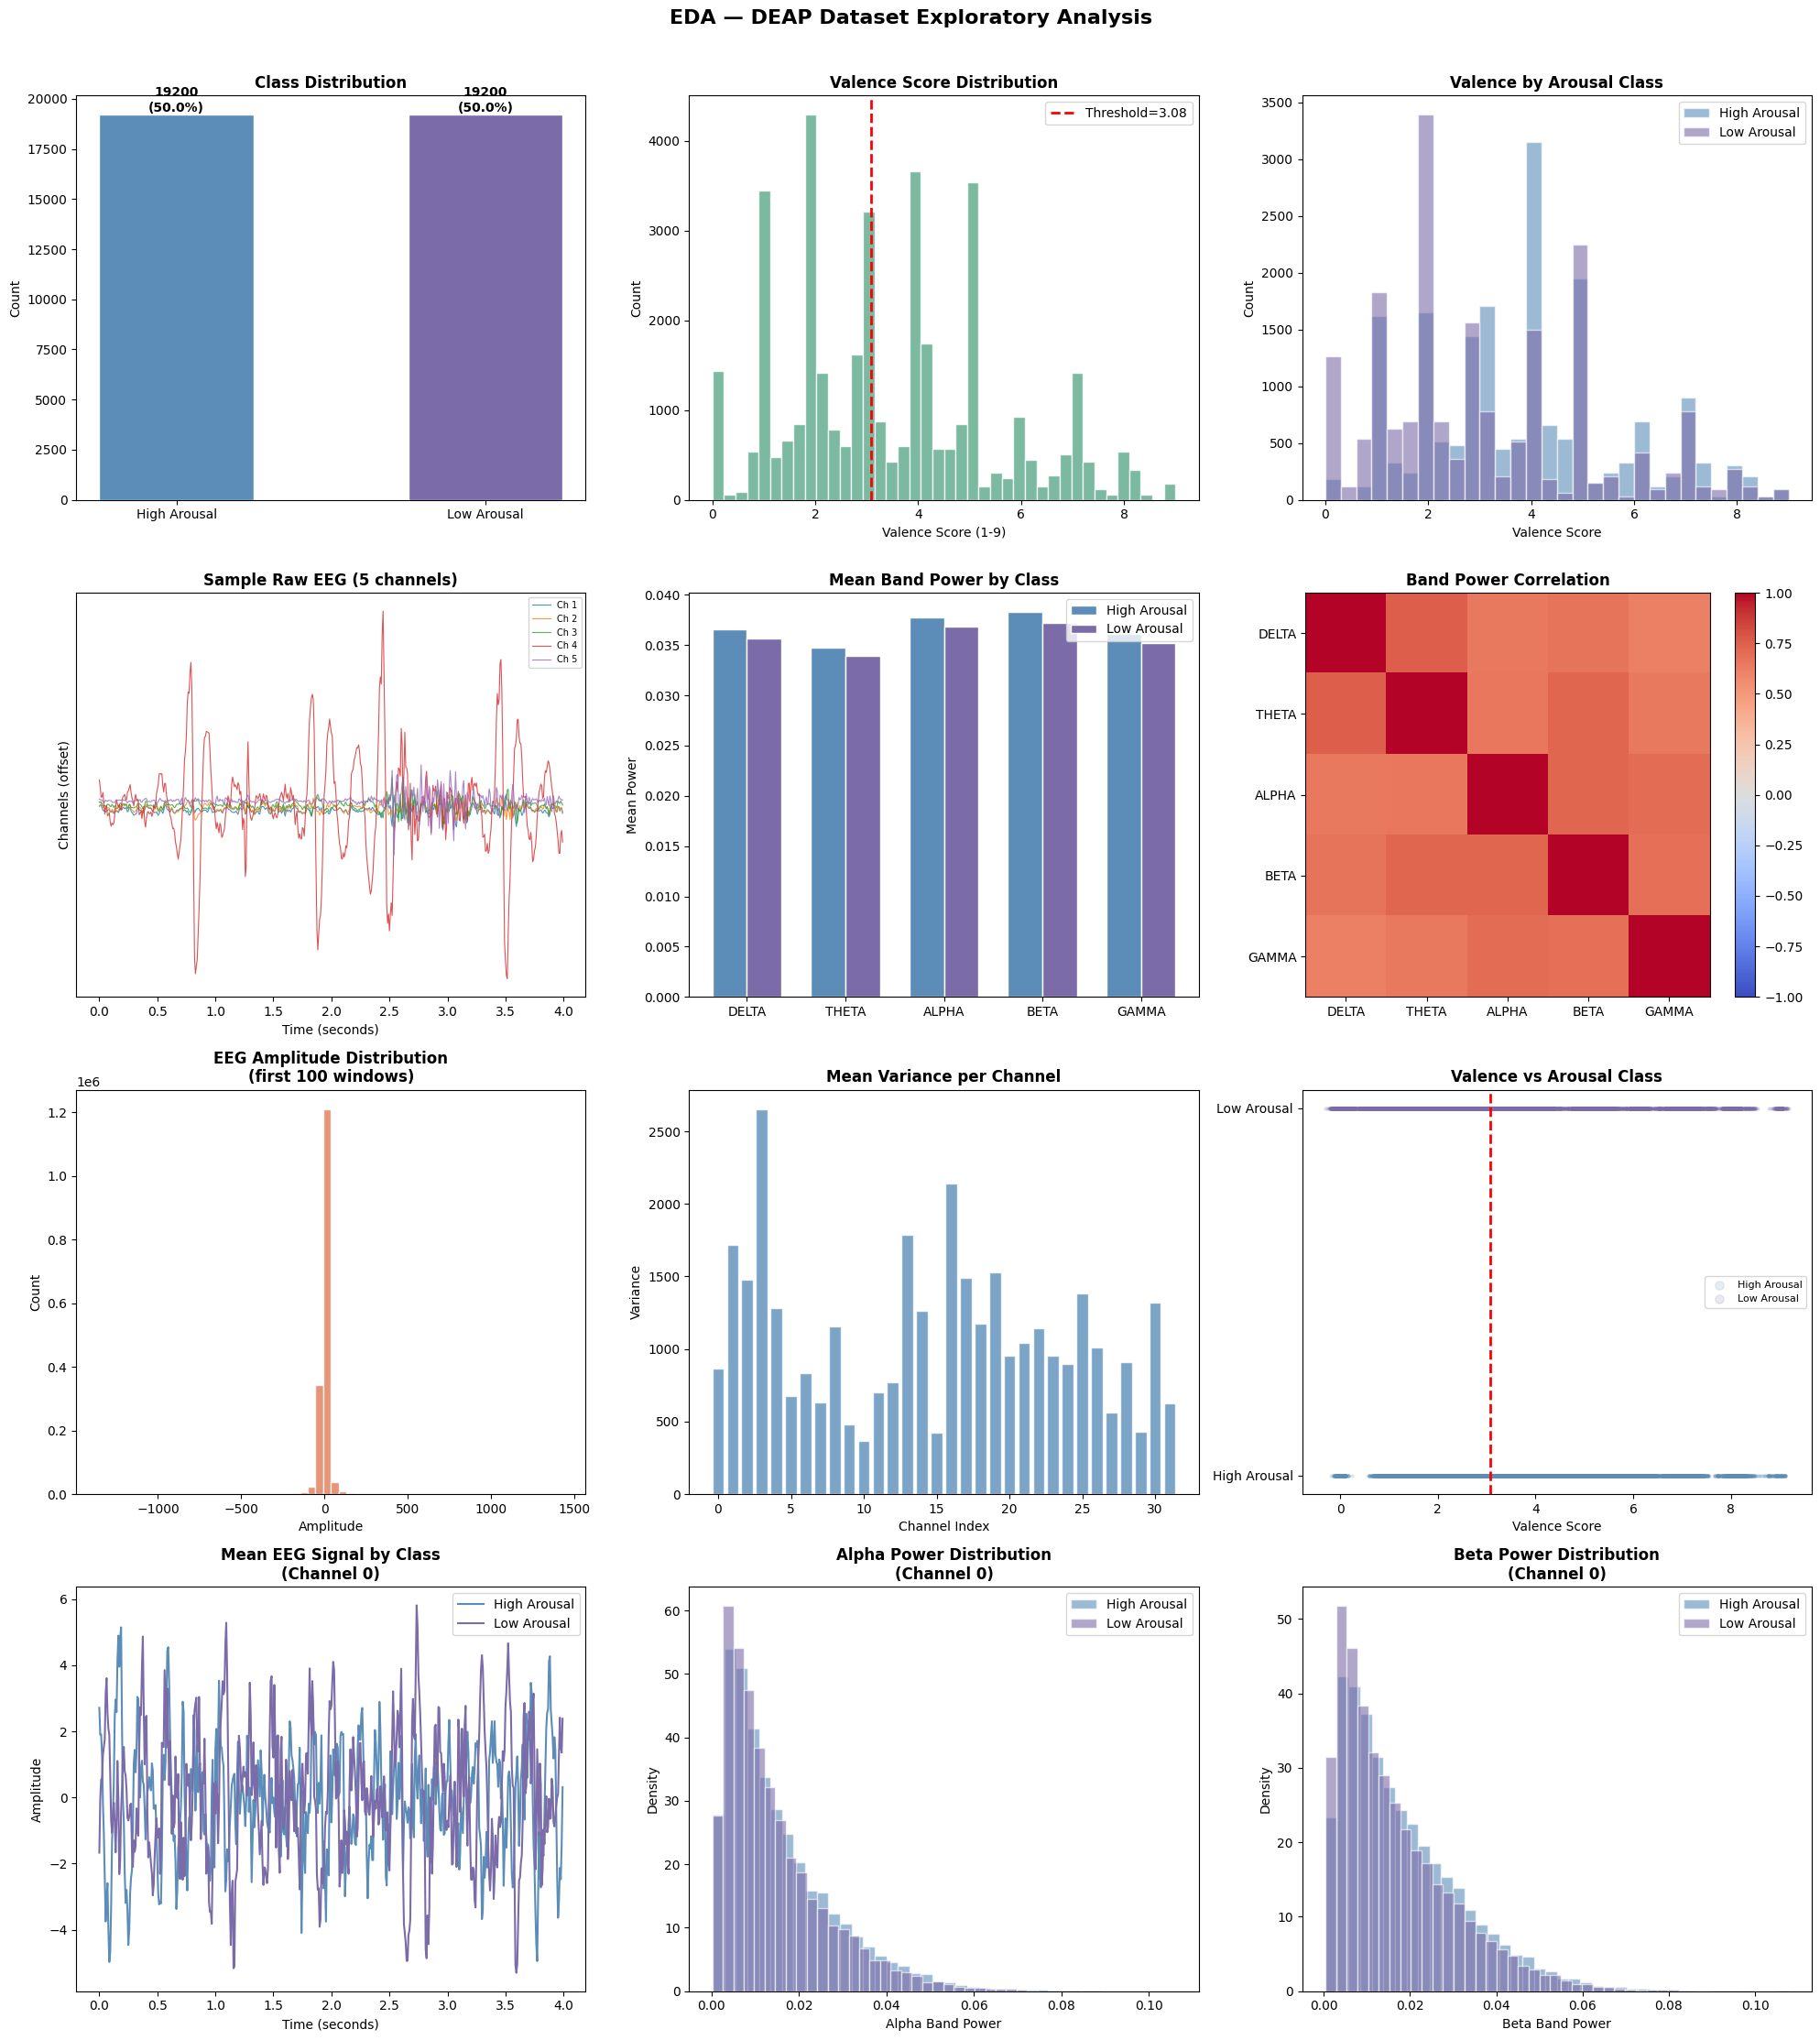

EDA complete. Saved eda_results.png


In [22]:
# ── EDA: Exploratory Data Analysis ───────────────────────────────────
print('Running EDA...')
print(f'Dataset shape : {raw_data.shape}')
print(f'Total windows : {len(raw_labels)}')
print()

fig = plt.figure(figsize=(20, 22))

# ── 1: Class Distribution ─────────────────────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
unique, counts = np.unique(raw_labels, return_counts=True)
bars = ax1.bar(cfg.CLASS_NAMES, counts, color=['#5B8DB8','#7B6BA8'], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             f'{cnt}\n({100*cnt/len(raw_labels):.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')

# ── 2: Valence Score Distribution ────────────────────────────────────
ax2 = fig.add_subplot(4, 3, 2)
ax2.hist(raw_valence, bins=40, color='#5BA88A', edgecolor='white', alpha=0.8)
ax2.axvline(cfg.VALENCE_THRESHOLD, color='red', ls='--', lw=2, label=f'Threshold={cfg.VALENCE_THRESHOLD}')
ax2.set_title('Valence Score Distribution', fontweight='bold')
ax2.set_xlabel('Valence Score (1-9)')
ax2.set_ylabel('Count')
ax2.legend()

# ── 3: Valence by Arousal Class ───────────────────────────────────────
ax3 = fig.add_subplot(4, 3, 3)
for cls, color, label in zip([0,1], ['#5B8DB8','#7B6BA8'], cfg.CLASS_NAMES):
    mask = raw_labels == cls
    ax3.hist(raw_valence[mask], bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
ax3.set_title('Valence by Arousal Class', fontweight='bold')
ax3.set_xlabel('Valence Score')
ax3.set_ylabel('Count')
ax3.legend()

# ── 4: Sample Raw EEG Signal ─────────────────────────────────────────
ax4 = fig.add_subplot(4, 3, 4)
sample = raw_data[0]
time   = np.arange(sample.shape[1]) / cfg.SAMPLING_RATE
for ch in range(5):
    ax4.plot(time, sample[ch] + ch*8, alpha=0.8, linewidth=0.8, label=f'Ch {ch+1}')
ax4.set_title('Sample Raw EEG (5 channels)', fontweight='bold')
ax4.set_xlabel('Time (seconds)')
ax4.set_ylabel('Channels (offset)')
ax4.set_yticks([])
ax4.legend(fontsize=7)

# ── 5: Mean Band Power per Class ─────────────────────────────────────
ax5 = fig.add_subplot(4, 3, 5)
band_names = list(cfg.BANDS.keys())
X_band_reshaped = X_band.reshape(len(X_band), cfg.N_CHANNELS, len(cfg.BANDS))
x_pos = np.arange(len(band_names))
width = 0.35
for offset, cls, color in zip([-width/2, width/2], [0,1], ['#5B8DB8','#7B6BA8']):
    mask = raw_labels == cls
    mean_bp = X_band_reshaped[mask].mean(axis=(0,1))
    ax5.bar(x_pos + offset, mean_bp, width, label=cfg.CLASS_NAMES[cls],
            color=color, edgecolor='white')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([b.upper() for b in band_names])
ax5.set_title('Mean Band Power by Class', fontweight='bold')
ax5.set_ylabel('Mean Power')
ax5.legend()

# ── 6: Band Power Correlation ─────────────────────────────────────────
ax6 = fig.add_subplot(4, 3, 6)
band_features = X_band[:, :len(cfg.BANDS)]
corr_matrix   = np.corrcoef(band_features.T)
im = ax6.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax6.set_xticks(range(len(band_names)))
ax6.set_yticks(range(len(band_names)))
ax6.set_xticklabels([b.upper() for b in band_names])
ax6.set_yticklabels([b.upper() for b in band_names])
plt.colorbar(im, ax=ax6)
ax6.set_title('Band Power Correlation', fontweight='bold')

# ── 7: EEG Amplitude Distribution ────────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
ax7.hist(raw_data[:100].flatten(), bins=60, color='#E07B54', edgecolor='white', alpha=0.8)
ax7.set_title('EEG Amplitude Distribution\n(first 100 windows)', fontweight='bold')
ax7.set_xlabel('Amplitude')
ax7.set_ylabel('Count')

# ── 8: Per-Channel Variance ───────────────────────────────────────────
ax8 = fig.add_subplot(4, 3, 8)
ch_var = raw_data.var(axis=2).mean(axis=0)
ax8.bar(range(cfg.N_CHANNELS), ch_var, color='#5B8DB8', edgecolor='white', alpha=0.8)
ax8.set_title('Mean Variance per Channel', fontweight='bold')
ax8.set_xlabel('Channel Index')
ax8.set_ylabel('Variance')

# ── 9: Valence vs Arousal Scatter ────────────────────────────────────
ax9 = fig.add_subplot(4, 3, 9)
for cls, color in zip([0,1], ['#5B8DB8','#7B6BA8']):
    mask = raw_labels == cls
    jitter = np.random.RandomState(42).normal(0, 0.08, mask.sum())
    ax9.scatter(raw_valence[mask] + jitter,
                np.full(mask.sum(), cls),
                alpha=0.15, color=color, label=cfg.CLASS_NAMES[cls], s=5)
ax9.axvline(cfg.VALENCE_THRESHOLD, color='red', ls='--', lw=2)
ax9.set_yticks([0,1])
ax9.set_yticklabels(cfg.CLASS_NAMES)
ax9.set_xlabel('Valence Score')
ax9.set_title('Valence vs Arousal Class', fontweight='bold')
ax9.legend(fontsize=8, markerscale=3)

# ── 10: Mean EEG Signal per Class ────────────────────────────────────
ax10 = fig.add_subplot(4, 3, 10)
time = np.arange(cfg.WINDOW_SAMPLES) / cfg.SAMPLING_RATE
for cls, color in zip([0,1], ['#5B8DB8','#7B6BA8']):
    mask = raw_labels == cls
    mean_sig = raw_data[mask][:200, 0, :].mean(axis=0)
    ax10.plot(time, mean_sig, color=color, label=cfg.CLASS_NAMES[cls], lw=1.5)
ax10.set_title('Mean EEG Signal by Class\n(Channel 0)', fontweight='bold')
ax10.set_xlabel('Time (seconds)')
ax10.set_ylabel('Amplitude')
ax10.legend()

# ── 11: Alpha Power by Class ──────────────────────────────────────────
ax11 = fig.add_subplot(4, 3, 11)
alpha_power = X_band[:, 2]   # alpha = index 2
for cls, color in zip([0,1], ['#5B8DB8','#7B6BA8']):
    mask = raw_labels == cls
    ax11.hist(alpha_power[mask], bins=40, alpha=0.6, color=color,
              label=cfg.CLASS_NAMES[cls], edgecolor='white', density=True)
ax11.set_title('Alpha Power Distribution\n(Channel 0)', fontweight='bold')
ax11.set_xlabel('Alpha Band Power')
ax11.set_ylabel('Density')
ax11.legend()

# ── 12: Beta Power by Class ───────────────────────────────────────────
ax12 = fig.add_subplot(4, 3, 12)
beta_power = X_band[:, 3]    # beta = index 3
for cls, color in zip([0,1], ['#5B8DB8','#7B6BA8']):
    mask = raw_labels == cls
    ax12.hist(beta_power[mask], bins=40, alpha=0.6, color=color,
              label=cfg.CLASS_NAMES[cls], edgecolor='white', density=True)
ax12.set_title('Beta Power Distribution\n(Channel 0)', fontweight='bold')
ax12.set_xlabel('Beta Band Power')
ax12.set_ylabel('Density')
ax12.legend()

plt.suptitle('EDA — DEAP Dataset Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_PATH}/eda_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA complete. Saved eda_results.png')

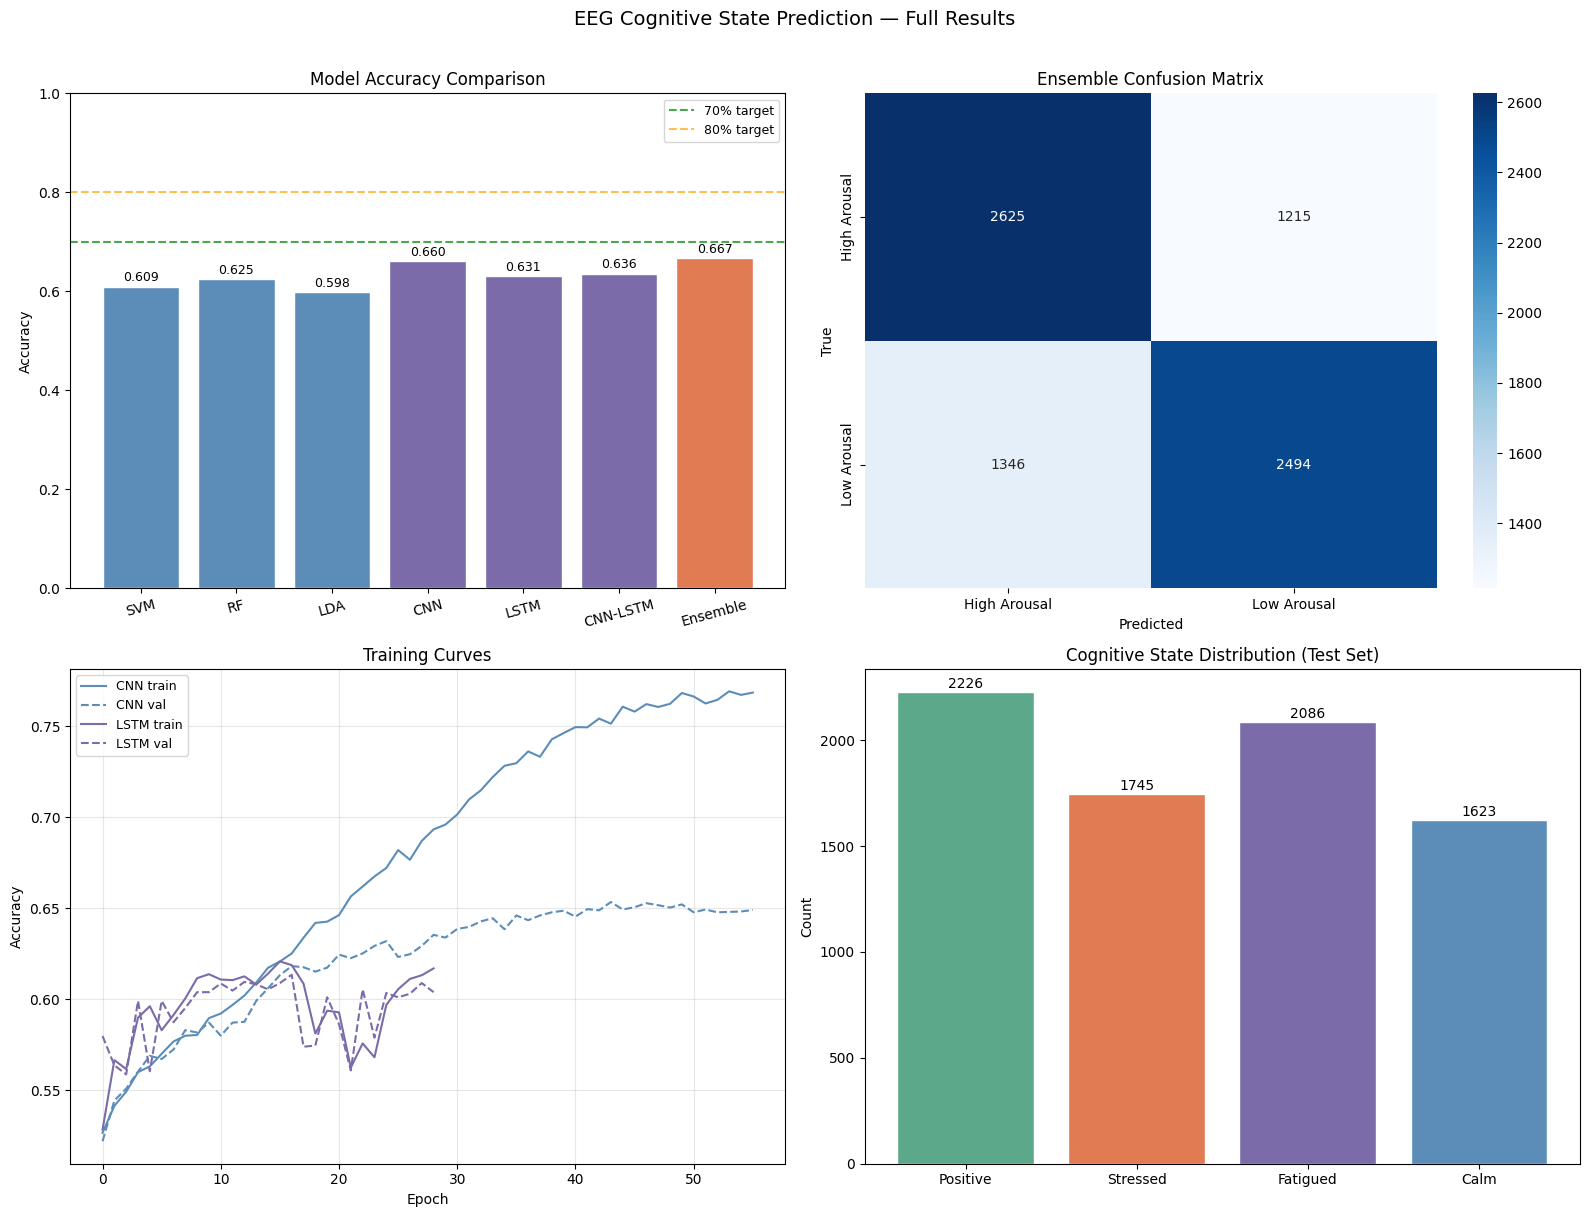

Saved results.png to /kaggle/working


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_accs = {
    'SVM': svm_acc, 'RF': rf_acc, 'LDA': lda_acc,
    'CNN': cnn_acc, 'LSTM': lstm_acc,
    'CNN-LSTM': cnn_lstm_acc, 'Ensemble': ensemble_acc
}

# Plot 1: Model Accuracy Comparison
ax = axes[0,0]
colors = ['#5B8DB8']*3 + ['#7B6BA8']*3 + ['#E07B54']
bars = ax.bar(model_accs.keys(), model_accs.values(), color=colors, edgecolor='white')
ax.axhline(0.70, color='green',  ls='--', alpha=0.7, label='70% target')
ax.axhline(0.80, color='orange', ls='--', alpha=0.7, label='80% target')
for bar, acc in zip(bars, model_accs.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.0); ax.set_title('Model Accuracy Comparison')
ax.set_ylabel('Accuracy'); ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=15)

# Plot 2: Confusion Matrix
ax = axes[0,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=cfg.CLASS_NAMES, yticklabels=cfg.CLASS_NAMES)
ax.set_title('Ensemble Confusion Matrix')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# Plot 3: Training Curves
ax = axes[1,0]
ax.plot(cnn_history.history['accuracy'],      label='CNN train',  color='#5B8DB8')
ax.plot(cnn_history.history['val_accuracy'],  label='CNN val',    color='#5B8DB8', ls='--')
ax.plot(lstm_history.history['accuracy'],     label='LSTM train', color='#7B6BA8')
ax.plot(lstm_history.history['val_accuracy'], label='LSTM val',   color='#7B6BA8', ls='--')
ax.set_title('Training Curves')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Plot 4: Cognitive State Distribution
ax = axes[1,1]
states  = ['Positive', 'Stressed', 'Fatigued', 'Calm']
scounts = [state_counts.get(s, 0) for s in states]
colors2 = ['#5BA88A', '#E07B54', '#7B6BA8', '#5B8DB8']
bars2   = ax.bar(states, scounts, color=colors2, edgecolor='white')
for bar, cnt in zip(bars2, scounts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(cnt), ha='center', va='bottom', fontsize=10)
ax.set_title('Cognitive State Distribution (Test Set)')
ax.set_ylabel('Count')

plt.suptitle('EEG Cognitive State Prediction — Full Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_PATH}/results.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved results.png to {cfg.OUTPUT_PATH}')

## 15. Final Summary

In [24]:
print('='*60)
print('   EEG COGNITIVE STATE PREDICTION — FINAL SUMMARY')
print('='*60)
print(f'  Dataset    : DEAP (32 subjects, 32 EEG channels)')
print(f'  Windows    : {len(raw_labels)} | 4s | 50% overlap')
print(f'  Split      : Train {len(y_train)} | Val {len(y_val)} | Test {len(y_test)}')
print(f'  Task       : Binary arousal (High vs Low)')
print(f'  Method     : Circumplex Model → 4 cognitive states')
print()
print(f'  {"Model":<12} {"Val Acc":>10} {"Test Acc":>10}')
print(f'  {"-"*35}')
print(f'  {"SVM":<12} {svm_val_acc:>10.4f} {svm_acc:>10.4f}')
print(f'  {"RF":<12} {rf_val_acc:>10.4f} {rf_acc:>10.4f}')
print(f'  {"LDA":<12} {lda_val_acc:>10.4f} {lda_acc:>10.4f}')
print(f'  {"CNN":<12} {cnn_val_acc:>10.4f} {cnn_acc:>10.4f}')
print(f'  {"LSTM":<12} {lstm_val_acc:>10.4f} {lstm_acc:>10.4f}')
print(f'  {"CNN-LSTM":<12} {cl_val_acc:>10.4f} {cnn_lstm_acc:>10.4f}')
print(f'  {"Ensemble":<12} {ensemble_val_acc:>10.4f} {ensemble_acc:>10.4f}')
print()
print(f'  Ensemble test accuracy : {ensemble_acc:.4f}')
print(f'  Uncertain flags        : {uncertain}/{len(confidences)}')
print()
print('  Cognitive states (test set):')
for state in ['Positive','Stressed','Fatigued','Calm']:
    cnt = state_counts.get(state, 0)
    print(f'    {state:10s}: {cnt} ({100*cnt/len(cognitive_states):.1f}%)')
print()
print('  Robustness:')
for t, r in rob_results.items():
    print(f'    {t:38s} acc={r["accuracy"]:.4f}  drop={r["drop"]:.4f}')
print('='*60)

   EEG COGNITIVE STATE PREDICTION — FINAL SUMMARY
  Dataset    : DEAP (32 subjects, 32 EEG channels)
  Windows    : 38400 | 4s | 50% overlap
  Split      : Train 26112 | Val 4608 | Test 7680
  Task       : Binary arousal (High vs Low)
  Method     : Circumplex Model → 4 cognitive states

  Model           Val Acc   Test Acc
  -----------------------------------
  SVM              0.6016     0.6090
  RF               0.6209     0.6247
  LDA              0.5929     0.5979
  CNN              0.6534     0.6603
  LSTM             0.6135     0.6307
  CNN-LSTM         0.6330     0.6355
  Ensemble         0.6543     0.6665

  Ensemble test accuracy : 0.6665
  Uncertain flags        : 3462/7680

  Cognitive states (test set):
    Positive  : 2226 (29.0%)
    Stressed  : 1745 (22.7%)
    Fatigued  : 2086 (27.2%)
    Calm      : 1623 (21.1%)

  Robustness:
    Gaussian noise (30%)                   acc=0.6341  drop=0.0324
    Missing channels (25%)                 acc=0.5682  drop=0.0983
    Inco

## 16. Save Models

In [25]:
import pickle as pkl

pkl.dump(svm_model,  open(f'{cfg.OUTPUT_PATH}/svm_model.pkl',  'wb'))
pkl.dump(rf_model,   open(f'{cfg.OUTPUT_PATH}/rf_model.pkl',   'wb'))
pkl.dump(lda_model,  open(f'{cfg.OUTPUT_PATH}/lda_model.pkl',  'wb'))
pkl.dump(scaler,     open(f'{cfg.OUTPUT_PATH}/scaler.pkl',     'wb'))

cnn_model.save(f'{cfg.OUTPUT_PATH}/cnn_model.keras')
lstm_model.save(f'{cfg.OUTPUT_PATH}/lstm_model.keras')
cnn_lstm_model.save(f'{cfg.OUTPUT_PATH}/cnn_lstm_model.keras')

np.save(f'{cfg.OUTPUT_PATH}/X_2d_mean.npy', X_2d_mean)
np.save(f'{cfg.OUTPUT_PATH}/X_2d_std.npy',  X_2d_std)

print(f'All models saved to: {cfg.OUTPUT_PATH}')
for f in sorted(os.listdir(cfg.OUTPUT_PATH)):
    size = os.path.getsize(f'{cfg.OUTPUT_PATH}/{f}') / 1024
    print(f'  {f:40s} {size:.0f} KB')

All models saved to: /kaggle/working
  .virtual_documents                       4 KB
  X_2d_mean.npy                            1 KB
  X_2d_std.npy                             1 KB
  best_cnn.keras                           5581 KB
  best_cnn_lstm.keras                      3968 KB
  best_lstm.keras                          1689 KB
  cnn_lstm_model.keras                     3968 KB
  cnn_model.keras                          5581 KB
  eda_results.png                          482 KB
  lda_model.pkl                            4 KB
  lstm_model.keras                         1689 KB
  results.png                              179 KB
  rf_model.pkl                             15438 KB
  robustness_results.png                   71 KB
  scaler.pkl                               4 KB
  svm_model.pkl                            4045 KB
